<h1 style="color: #3EB489; font-size: 40px;">Introduction</h1>

<h2 style="color: #3EB489; 
           font-size: 20px;
           line-height: 1.5;
           margin-bottom: 20px;"> The following notebook employ predictive methods for learning the price of houses from India using a set of various predictors. Three methods are directly compared to each other:
    <ul>
      <li>Untuned LGBMRegressor (Test R-square of <u>0.8878</u>)</li>
      <li>Tuned LGBMRegressor (Test R-square of <u>0.8937</u>)</li>
      <li>Ensemble of 8 Tuned LGBMRegressors (Test R-square of <u>0.8944</u>)</li>
    </ul>
    The highest performing model is the ensemble, although the performance still pales when compared to GAM model from my <a href="https://www.kaggle.com/code/khoatran311/explain-90-of-the-data-with-gam-in-r">R notebook</a>, with <u>0.907</u> as the test R-square score. Note that this is not an exploratory analysis notebook; all exploratory analysis have already been performed on my R notebook, which you are free to visit and see. 
</h2>

In [1]:
!pip install optuna

In [2]:
pip install numpy pandas seaborn matplotlib scipy scikit-learn optuna xgboost lightgbm

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ----

In [3]:
import numpy as np
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt
from scipy.stats import t

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import optuna

import xgboost, lightgbm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

<h1 style="color: #3EB489; font-size: 40px;">Data Processing</h1>

<h2 style="color: #3EB489; 
           font-size: 20px;
           line-height: 1.5;
           margin-bottom: 20px;"> The majority of data analysis required for understanding the processing of this data was already performed in my <a href="https://www.kaggle.com/code/khoatran311/explain-90-of-the-data-with-gam-in-r">R notebook</a>. Briefly, 
    <ul>
      <li>Certain skewed features are transformed using the logairthm</li>
      <li>A binary version of the predictor renovated_year is created; renovated_year is then dropped</li>
      <li>Only samples with number_of_bedrooms being less than 20 are used</li>
      <li>Rounded number_of_bathrooms predictor</li>
    </ul>
</h2>

In [ ]:
class Constants:
    SEED = 3126
    KFOLD10 = KFold(n_splits=10, shuffle=True, random_state=3126)
    KFOLD5 = KFold(n_splits=5, shuffle=True, random_state=3126)
    PREPROC = None

In [ ]:
data = pd.read_csv("//house-prices-india/House Price India.csv")

In [4]:
### Remove id and Date features
features = [feature for feature in data.columns if feature not in ("id","Date")]
subset = data.loc[:, features]

### Substitute spaces with underscores; lowercase all features
subset.columns = subset.columns.str.replace(" ", "_").str.lower()

### Rename one feature with parenthesis
subset.rename(columns={"area_of_the_house(excluding_basement)":"area_of_house_noBasement"},
              inplace=True)

### Log transform certain skewed features
skewed_features = ["area_of_the_basement", "lot_area", "area_of_house_noBasement", 
                   "lot_area_renov", "living_area_renov", "living_area"]
subset[skewed_features] = subset[skewed_features].apply(lambda x: np.log10(1+x))

### Binarize renovation_year -> renovated
subset["renovated"] = np.where(subset["renovation_year"]==0, 0, 1)

### Filter only number_of_bedrooms < 20
subset = subset.loc[subset.number_of_bedrooms < 20]

### Round number_of_bathrooms 
subset["number_of_bathrooms"] = np.round(subset["number_of_bathrooms"])

# Drop column
subset.drop("renovation_year", axis=1, inplace=True)

<h1 style="color: #3EB489; font-size: 40px;">Data Modeling with LGBMRegressors</h1>


In [5]:
X = subset.copy()
y = X.pop("price")

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=.25, shuffle=True, random_state=Constants.SEED)

X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [6]:
lgbm_params = {"objective":"regression",
               "random_state":Constants.SEED,
               "early_stopping_round":50,
               "n_jobs":-1,
               "verbosity":-1
              }

In [7]:
def cv_evaluate(classifier, X, y, cv_method, scoring_method):
    train_scores, val_scores = [], []  

    for train_idx, val_idx in cv_method.split(X, y):
        X_t, y_t = X.iloc[train_idx], y[train_idx]
        X_v, y_v = X.iloc[val_idx],   y[val_idx]
        ### Log transform targets
        y_t, y_v = np.log(y_t), np.log(y_v)
        
        classifier.fit(X_t, y_t, 
                       eval_set=[(X_v,y_v)])
        y_train_pred = classifier.predict(X_t) ## log form
        y_val_pred = classifier.predict(X_v) ## log form
        
        ### Undo Log transformation of predictions and target
        y_t, y_v = np.exp(y_t), np.exp(y_v)
        y_train_pred, y_val_pred = np.exp(y_train_pred), np.exp(y_val_pred)
        ### Obtain and append scores
        train_score = scoring_method(y_t, y_train_pred)
        val_score   = scoring_method(y_v, y_val_pred)
        train_scores.append(train_score)
        val_scores.append(val_score)
    
    train_scores = np.array(train_scores)
    val_scores   = np.array(val_scores)
    
    return val_scores, train_scores

In [8]:
def plot_performance(val_scores, train_scores, classifier_name, x_range=np.arange(1,11)):
    
    performance = pd.DataFrame({"val_scores":val_scores,
                                "train_scores":train_scores
                               })
    
    t_stat = t.ppf(.975, df=10 - 1)
    print(f"95% C.I. for Train R-square score: {performance.train_scores.mean():.4f} ± {t_stat*performance.train_scores.std()/np.sqrt(10):.4f}")
    print(f"95% C.I. for Validation R-square score: {performance.val_scores.mean():.4f} ± {t_stat*performance.val_scores.std()/np.sqrt(10):.4f}")
    print()
    
    fig,ax = plt.subplots(1,1)
    sea.scatterplot(x=x_range, y=performance.val_scores, color="#E89C31", ax=ax)
    sea.lineplot(x=x_range, y=performance.val_scores, label="Validation set", color="#E89C31", ax=ax)

    sea.scatterplot(x=x_range, y=performance.train_scores, color="#7F3C8D", ax=ax)
    sea.lineplot(x=x_range, y=performance.train_scores, label="Train set", color="#7F3C8D", ax=ax)
    
    plt.legend()
    ax.set_ylim(.6, 1)
    ax.set_xlabel("Validation Fold Iteration")
    ax.set_ylabel("R-square Score")
    ax.set_title(f"{classifier_name}'s Predictive Performance")
    plt.show()

<h2 style="color: #3EB489; 
           font-size: 25px;
           line-height: 1.5;
           margin-bottom: 20px;"> Baseline LGBMRegressor 1
</h2>

95% C.I. for Train R-square score: 0.9453 ± 0.0013
95% C.I. for Validation R-square score: 0.8946 ± 0.0220



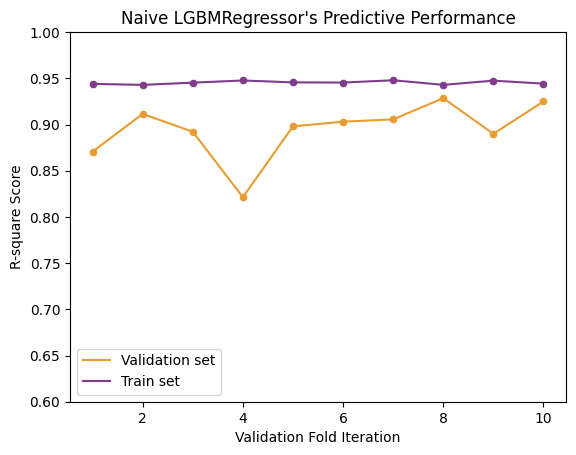

In [9]:
lgbm_null = LGBMRegressor(**lgbm_params)

val_scores, train_scores = cv_evaluate(lgbm_null, X_train, y_train,
                                       Constants.KFOLD10, r2_score)
plot_performance(val_scores, train_scores, "Naive LGBMRegressor")

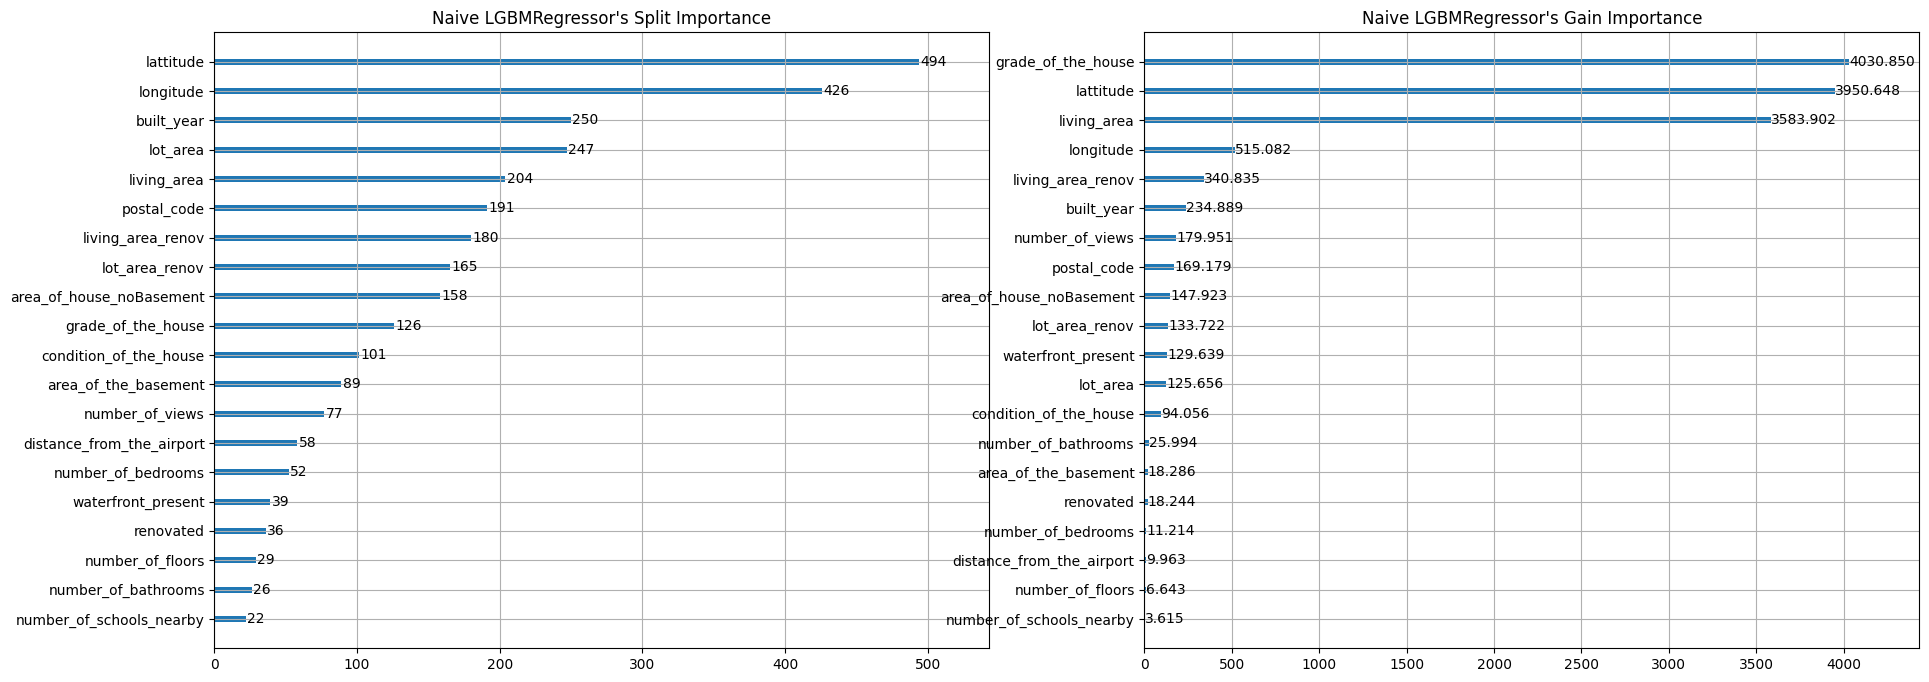

In [10]:
fig,axes = plt.subplots(1,2, figsize=(22,8))
lightgbm.plot_importance(lgbm_null, importance_type="split", title="Naive LGBMRegressor's Split Importance", ax=axes[0],
                         ylabel=None, xlabel=None)
lightgbm.plot_importance(lgbm_null, importance_type="gain", title="Naive LGBMRegressor's Gain Importance", ax=axes[1],
                         ylabel=None, xlabel=None)

plt.show()

<h2 style="color: #3EB489; 
           font-size: 25px;
           line-height: 1.5;
           margin-bottom: 20px;"> Baseline LGBMRegressor 2
</h2>

In [11]:
class DropFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_new = X.copy()
        X_new.drop(columns=self.features, inplace=True)
        return X_new

In [12]:
Constants.PREPROC = make_pipeline(DropFeatures(["number_of_schools_nearby", "distance_from_the_airport"])
                                 )

95% C.I. for Train R-square score: 0.9451 ± 0.0013
95% C.I. for Validation R-square score: 0.8968 ± 0.0220



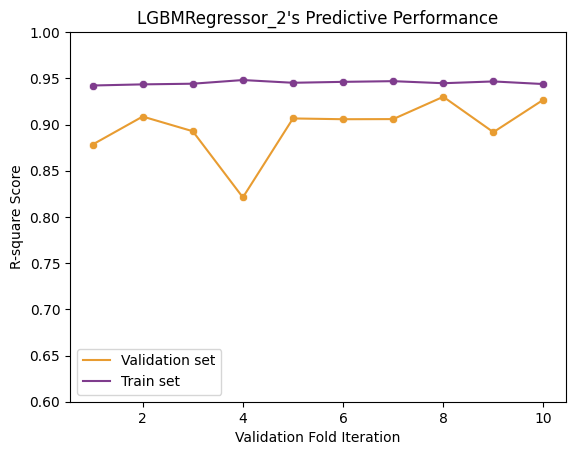

In [13]:
### Drop number_of_schools_nearby, distance_from_the_airport
lgbm2 = LGBMRegressor(**lgbm_params)
X_train_2 = Constants.PREPROC.fit_transform(X_train)

### Evaluate
val_scores, train_scores = cv_evaluate(lgbm2, X_train_2, y_train, 
                                       Constants.KFOLD10, r2_score)
plot_performance(val_scores, train_scores, "LGBMRegressor_2")

<h2 style="color: #3EB489; 
           font-size: 25px;
           line-height: 1.5;
           margin-bottom: 20px;"> Baseline LGBMRegressor 3
</h2>

In [14]:
class NewFeatures(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_new = X.copy()
        X_new["year_groups"] = np.where(X_new.built_year<=1940, 0,
                                        np.where(X_new.built_year<=1960, 1, 
                                                      np.where(X_new.built_year<=2000, 2, 3)
                                                 )
                                       )
        X_new["longitude_groups"] = np.where(X_new.longitude<=-114.0, 1, 0)
        X_new["lattitude_groups"] = np.where(X_new.lattitude<=52.7, 1, 0)        
        return X_new

In [15]:
Constants.PREPROC = make_pipeline(DropFeatures(["number_of_schools_nearby", "distance_from_the_airport"]),
                                  NewFeatures()
                                 )

95% C.I. for Train R-square score: 0.9452 ± 0.0013
95% C.I. for Validation R-square score: 0.8962 ± 0.0223



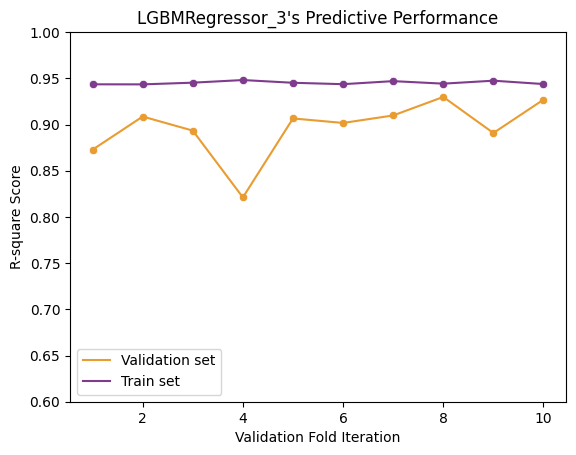

In [16]:
lgbm3 = LGBMRegressor(**lgbm_params)
X_train_3 = Constants.PREPROC.fit_transform(X_train)

### Evaluate
val_scores, train_scores = cv_evaluate(lgbm3, X_train_3, y_train,
                                       Constants.KFOLD10, r2_score)
plot_performance(val_scores, train_scores, "LGBMRegressor_3")

<h2 style="color: #3EB489; 
           font-size: 25px;
           line-height: 1.5;
           margin-bottom: 20px;"> Optimized LGBMRegressor
</h2>

In [17]:
def lgbm_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 5000, step=150)
    max_depth = trial.suggest_int("max_depth", 1, 15)
    learning_rate = trial.suggest_float("learning_rate", .00655, .25, log=True)
    num_leaves = trial.suggest_int("num_leaves", 30, 300, step=10)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-9, 8, log=True)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-9, 8, log=True)
    colsample_bytree = trial.suggest_float("colsample_bytree", .3, .7)
    
    params = {"n_estimators":n_estimators,
              "max_depth":max_depth,
              "learning_rate":learning_rate,
              "num_leaves":num_leaves,
              "reg_lambda":reg_lambda,
              "reg_alpha":reg_alpha,
              "colsample_bytree":colsample_bytree,
             }
    params["objective"] = "regression"
    params["random_state"] = Constants.SEED
    params["early_stopping_round"] = 50
    params["n_jobs"] = -1
    params["verbosity"] = -1
    
    lgbm = LGBMRegressor(**params)
    val_scores,_ = cv_evaluate(lgbm, X_train_3, y_train,
                               Constants.KFOLD10, r2_score)
    return val_scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(lgbm_objective, n_trials=100)

95% C.I. for Train R-square score: 0.9494 ± 0.0027
95% C.I. for Validation R-square score: 0.9015 ± 0.0232



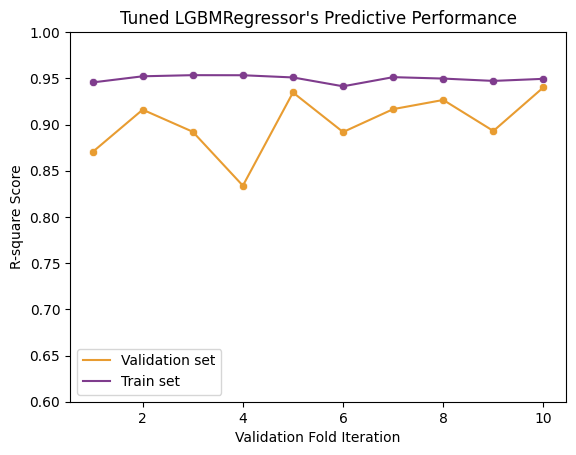

In [18]:
lgbm_params = {'n_estimators': 2800,
               'max_depth': 4,
               'learning_rate': 0.031272307140694025,
               'num_leaves': 240,
               'reg_lambda': 0.12728375970489764,
               'reg_alpha': 1.0343377121907666,
               'colsample_bytree': 0.48343714655493997
              }
lgbm_params["objective"] = "regression"
lgbm_params["random_state"] = Constants.SEED
lgbm_params["early_stopping_round"] = 50
lgbm_params["n_jobs"] = -1
lgbm_params["verbosity"] = -1


lgbm = LGBMRegressor(**lgbm_params)
val_scores, train_scores = cv_evaluate(lgbm, X_train_3, y_train,
                                       Constants.KFOLD10, r2_score)
plot_performance(val_scores, train_scores, "Tuned LGBMRegressor")

In [19]:
X_test_3 = Constants.PREPROC.transform(X_test)
y_test_pred_tuned = np.exp(lgbm.predict(X_test_3))
y_test_pred = np.exp(lgbm3.predict(X_test_3))

rsq_score_tuned = r2_score(y_test, y_test_pred_tuned)
rsq_score = r2_score(y_test, y_test_pred)

print(f"R-square Score for Test Set using Tuned LGBMRegressor: {rsq_score_tuned:.4f}")
print(f"R-square Score for Test Set using Untuned LGBMRegressor: {rsq_score:.4f}")

R-square Score for Test Set using Tuned LGBMRegressor: 0.8937
R-square Score for Test Set using Untuned LGBMRegressor: 0.8878


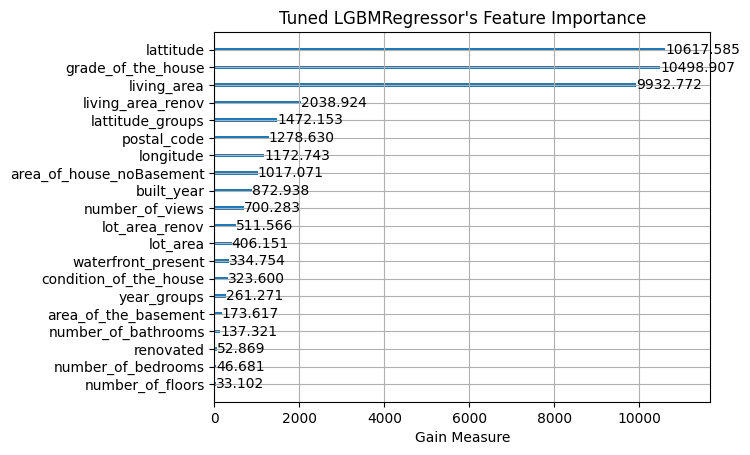

In [20]:
lightgbm.plot_importance(lgbm, importance_type="gain", title="Tuned LGBMRegressor's Feature Importance", 
                         ylabel=None, xlabel="Gain Measure")
plt.show()

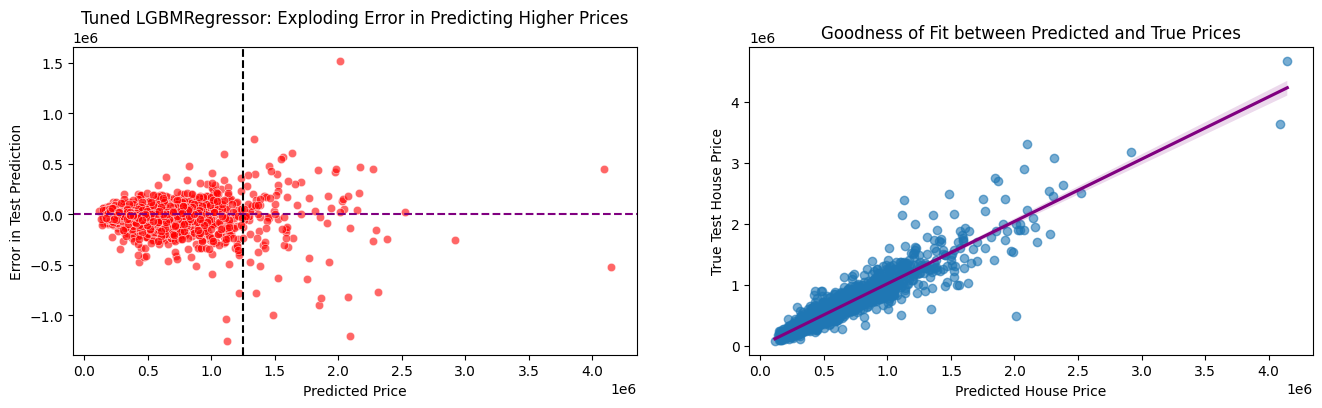

In [21]:
fig,axes = plt.subplots(1, 2, figsize=(16,4))

sea.scatterplot(x=y_test_pred_tuned, 
                y=y_test_pred_tuned-y_test, 
                alpha=.6,
                color="red",
                ax=axes[0])
axes[0].axhline(0, color="purple", linestyle="--")
axes[0].axvline(1.25e6, color="black", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Error in Test Prediction")
axes[0].set_title("Tuned LGBMRegressor: Exploding Error in Predicting Higher Prices")


sea.regplot(x=y_test_pred_tuned, 
            y=y_test, 
            scatter_kws={'alpha': 0.6}, 
            ax=axes[1], 
            line_kws={'color': 'purple'}
           )

axes[1].set_ylabel("True Test House Price")
axes[1].set_xlabel("Predicted House Price")
axes[1].set_title("Goodness of Fit between Predicted and True Prices")
plt.show()

<h2 style="color: #3EB489; 
           font-size: 25px;
           line-height: 1.5;
           margin-bottom: 20px;"> LGBMRegressor Ensemble
</h2>

In [22]:
### Different seeds (8 total)
seeds = [42, 39, 189, 96, 135, 666, 999, Constants.SEED]
lgbm_variations = {}

lgbm_params = {'n_estimators': 2800,
               'max_depth': 4,
               'learning_rate': 0.031272307140694025,
               'num_leaves': 240,
               'reg_lambda': 0.12728375970489764,
               'reg_alpha': 1.0343377121907666,
               'colsample_bytree': 0.48343714655493997
              }
lgbm_params["objective"] = "regression"
lgbm_params["early_stopping_round"] = 50
lgbm_params["n_jobs"] = -1
lgbm_params["verbosity"] = -1


for k,seed in enumerate(seeds):
    lgbm_params["random_state"] = seed
    lgbm = LGBMRegressor(**lgbm_params)
    _,_  = train_scores = cv_evaluate(lgbm, X_train_3, y_train,
                                      Constants.KFOLD10, r2_score)
    lgbm_variations[f"lgbm_{seed}"] = lgbm
    print(f"Finished Iteration {k+1}!")

Finished Iteration 1!
Finished Iteration 2!
Finished Iteration 3!
Finished Iteration 4!
Finished Iteration 5!
Finished Iteration 6!
Finished Iteration 7!
Finished Iteration 8!


In [23]:
lgbm_predictions = {}
for name,regressor in lgbm_variations.items():
    lgbm_predictions[name] = np.exp(regressor.predict(X_test_3))
    
y_test_pred_ensemble = np.array(pd.DataFrame(lgbm_predictions).mean(axis=1))
ensemble_r2 = r2_score(y_test, y_test_pred_ensemble)

print(f"R-square Score for Test Set using Ensemble of 8 Tuned LGBMRegressors: {ensemble_r2:.4f}")
print(f"R-square Score for Test Set using Tuned LGBMRegressor: {rsq_score_tuned:.4f}")
print(f"R-square Score for Test Set using Untuned LGBMRegressor: {rsq_score:.4f}")

R-square Score for Test Set using Ensemble of 8 Tuned LGBMRegressors: 0.8944
R-square Score for Test Set using Tuned LGBMRegressor: 0.8937
R-square Score for Test Set using Untuned LGBMRegressor: 0.8878


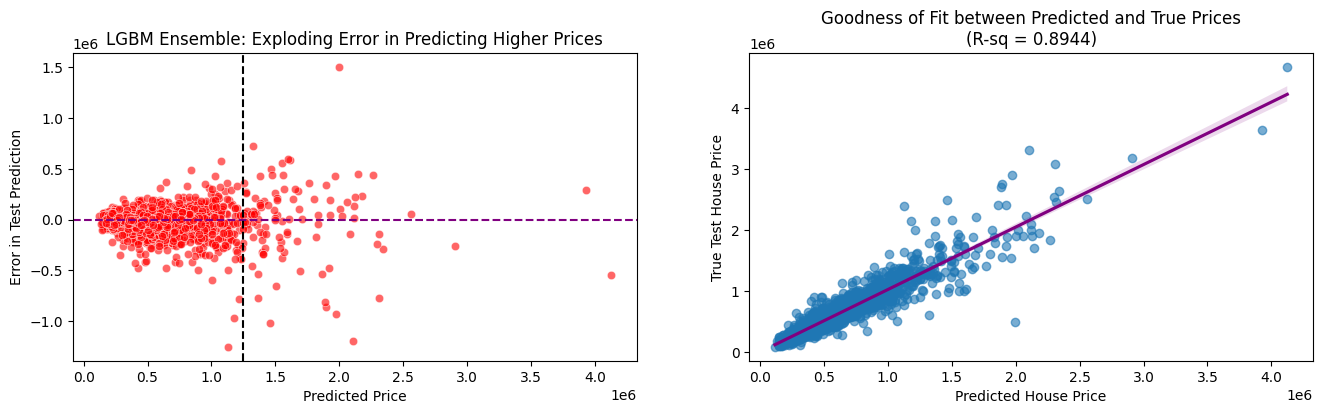

In [24]:
fig,axes = plt.subplots(1, 2, figsize=(16,4))

sea.scatterplot(x=y_test_pred_ensemble, 
                y=y_test_pred_ensemble-y_test, 
                alpha=.6,
                color="red",
                ax=axes[0])
axes[0].axhline(0, color="purple", linestyle="--")
axes[0].axvline(1.25e6, color="black", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Error in Test Prediction")
axes[0].set_title("LGBM Ensemble: Exploding Error in Predicting Higher Prices")


sea.regplot(x=y_test_pred_ensemble, 
            y=y_test, 
            scatter_kws={'alpha': 0.6}, 
            ax=axes[1], 
            line_kws={'color': 'purple'}
           )

axes[1].set_ylabel("True Test House Price")
axes[1].set_xlabel("Predicted House Price")
axes[1].set_title("Goodness of Fit between Predicted and True Prices\n(R-sq = 0.8944)")
plt.show()

<h1 style="color: #3EB489; font-size: 40px;">Conclusion</h1>

<h2 style="color: #3EB489; 
           font-size: 20px;
           line-height: 1.5;
           margin-bottom: 20px;"> The best model achieved here is an ensemble of several tuned LGBMRegressor with different seeds, with <u>0.8944</u> as the best attained R-square score. This is still underperforming, however, when compared with my GAM model which achieved a higher value of <u>0.907</u> for its R-square value. But why do both seems stuck around the mark of approximately 0.900 for their R-square values? I have two hypotheses:
    <ul>
      <li>The few number of houses having prices exceeding 1.25e6 increases the learning challenge</li>
      <li>Houses having prices above 1.25e6 may share close data characteristics with houses having lesser values; this is observed in higher-costing houses always being underestimated (most red error dots are below zero for these houses!)</li>
    To improve model performance, we could remove these house prices which exceeds 1.25e6, but that would result in poor performance when faced with estimating these prices in the future. 
    </ul>
</h2>

<h2 style="color: #3EB489; 
           font-size: 25px;
           line-height: 1.5;
           margin-bottom: 20px;"> Thank you so much for reading!
</h2>